# Proyecto de Analítica de Datos — Corte 2
## Grupo 5: Experiencia de compra en comercio electrónico

**Integrantes:** 

**Dataset:** `grupo05_experiencia_ecommerce.csv`

**Pregunta guía:** ¿Qué factores de la experiencia de compra explican la satisfacción y permiten anticipar una devolución?

El notebook sigue las fases de CRISP-DM y se ejecuta de inicio a fin sin intervención manual (`Kernel > Restart & Run All`).

## Fase 1 — Comprensión del negocio

### 1.1 Contexto
Un comercio electrónico registra, para cada pedido, atributos del producto, condiciones comerciales, historial del cliente y resultados posteriores a la compra. Cada devolución genera costos de logística inversa, revisión del producto y margen perdido. La unidad de análisis es un pedido (una fila del dataset).

### 1.2 Pregunta analítica
Con la información disponible al confirmarse la entrega de un pedido, ¿qué factores se asocian con la devolución y es posible estimar su probabilidad con un desempeño suficiente para priorizar un contacto preventivo con el cliente?

El momento de la predicción se fija después de la entrega porque dos predictores importantes, `dias_entrega` y `compatibilidad_expectativa_1_10`, solo se conocen cuando el cliente ya recibió el producto. Usarlos para predecir antes del despacho sería usar información que todavía no existe.

### 1.3 Ruta elegida: Ruta B — Clasificación
**Variable objetivo:** `devuelve_producto` (1 = el pedido terminó en devolución, 0 = no).

**Razones desde el negocio:** la devolución es un evento concreto, con costo directo y con una ventana de intervención entre la entrega y la decisión del cliente. La satisfacción es una calificación autorreportada cuyo impacto económico es indirecto.

**Razones desde los datos** (sección 2.8):
- `satisfaccion_postcompra_1_10` tiene un efecto techo: el 24,73% de los pedidos vale exactamente 10 y la asimetría es −0,92, lo que dificulta una regresión lineal.
- La satisfacción depende casi solo de `dias_entrega` (R² = 0,287); agregar los otros ocho predictores numéricos solo sube el R² a 0,370.
- La devolución, en cambio, se relaciona con varios predictores a la vez, sin uno dominante, que es donde un modelo multivariado aporta.

La parte de la pregunta guía sobre satisfacción se responde de forma descriptiva en las secciones 2.8 y 6.3.

### 1.4 Decisión que apoya el modelo
- **Servicio al cliente:** priorizar qué pedidos contactar después de la entrega (soporte, cambio de talla, guía de uso).
- **Catálogo y logística:** usar los factores identificados para reducir devoluciones evitables.

El modelo prioriza la atención; no bloquea pedidos ni toma decisiones automáticas sobre clientes.

### 1.5 Supuestos
- `devuelve_producto` incluye cualquier retorno del producto, sin distinguir el motivo.
- `compatibilidad_expectativa_1_10` es reportada por el cliente al recibir el producto.
- La ventana de devolución es la misma para todos los pedidos.

## Fase 2 — Comprensión de los datos

In [1]:
# ============================================================
# 2.1 Configuración del entorno y semilla de reproducibilidad
# ============================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels
import statsmodels.api as sm

# Semilla única, reutilizada en partición, validación cruzada y modelos
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style='whitegrid')

# Constantes del proyecto
RUTA_DATOS    = 'grupo05_experiencia_ecommerce.csv'
TARGET        = 'devuelve_producto'               # Ruta B: objetivo binario
OTRO_OBJETIVO = ['satisfaccion_postcompra_1_10']  # objetivo de la Ruta A -> se excluye de X
IDENTIF       = ['id_pedido']                     # identificador -> se excluye de X

print(f"Python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"statsmodels : {statsmodels.__version__}")
print(f"Semilla     : {RANDOM_STATE}")

Python      : 3.12.3
numpy       : 2.4.4
pandas      : 3.0.2
scikit-learn: 1.8.0
statsmodels : 0.15.0
Semilla     : 42


In [2]:
# ============================================================
# 2.2 Carga y revisión de estructura
# ============================================================
df = pd.read_csv(RUTA_DATOS)

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("Tipos de dato:")
print(df.dtypes.to_string())

print("\nRangos de las variables numéricas:")
display(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].round(2))

CATEGORICAS = ['categoria_producto', 'metodo_pago']
for c in CATEGORICAS:
    print(f"\n--- {c} ({df[c].nunique()} niveles)")
    display(pd.DataFrame({'frecuencia': df[c].value_counts(),
                          'pct': (df[c].value_counts(normalize=True) * 100).round(2)}))

Dimensiones: 1108 filas x 16 columnas

Tipos de dato:
id_pedido                            int64
categoria_producto                     str
precio_producto_cop                  int64
descuento_pct                      float64
dias_entrega                       float64
calificacion_producto              float64
num_resenas_producto                 int64
antiguedad_cliente_meses             int64
compras_12m                          int64
devoluciones_previas_12m             int64
metodo_pago                            str
envio_express                        int64
descripcion_completa                 int64
compatibilidad_expectativa_1_10    float64
satisfaccion_postcompra_1_10       float64
devuelve_producto                    int64

Rangos de las variables numéricas:


,count,mean,std,min,50%,max
id_pedido,1108.0,550.12,317.54,1.00,550.50,1100.0
precio_producto_cop,1108.0,245761.43,246378.26,18000.00,169348.00,2400000.0
descuento_pct,1108.0,15.75,8.73,0.60,14.50,45.6
dias_entrega,1090.0,4.53,2.49,1.20,3.90,14.0
calificacion_producto,1090.0,4.30,0.42,2.96,4.31,5.0
num_resenas_producto,1108.0,89.62,110.58,2.00,53.00,894.0
antiguedad_cliente_meses,1108.0,37.59,21.21,1.00,38.00,72.0
compras_12m,1108.0,7.48,2.74,0.00,7.00,17.0
devoluciones_previas_12m,1108.0,1.05,1.01,0.00,1.00,7.0
envio_express,1108.0,0.30,0.46,0.00,0.00,1.0



--- categoria_producto (5 niveles)


,frecuencia,pct
categoria_producto,,
moda,272,24.55
hogar,246,22.20
tecnologia,221,19.95
deporte,197,17.78
belleza,172,15.52



--- metodo_pago (4 niveles)


,frecuencia,pct
metodo_pago,,
tarjeta,427,38.54
pse,318,28.70
billetera,229,20.67
contraentrega,134,12.09


**Observaciones:**
- 1.108 filas y 16 columnas. Solo `categoria_producto` (5 niveles) y `metodo_pago` (4 niveles) son categóricas.
- Los rangos son coherentes: descuentos entre 0,6% y 45,6%, días de entrega entre 1,2 y 14, escalas 1-10 dentro de su rango y sin negativos.
- `id_pedido` llega hasta 1.100 pero hay 1.108 filas, lo que indica identificadores repetidos (sección 2.4).
- `envio_express` y `descripcion_completa` son binarias 0/1: no necesitan codificación ni escalamiento.
- `precio_producto_cop` y `num_resenas_producto` tienen colas largas (media muy por encima de la mediana).

In [3]:
# ============================================================
# 2.3 Diccionario de variables
# "Se conoce" indica en qué momento del pedido está disponible el dato;
# se usa en la sección 2.7 para el control de fuga.
# ============================================================
diccionario = pd.DataFrame([
    ('id_pedido',                       'Identificador', 'Clave del pedido',                                          'Compra',  'Excluir (identificador)'),
    ('categoria_producto',              'Categórica',    'Categoría comercial del producto (5 niveles)',              'Compra',  'Predictor (one-hot)'),
    ('precio_producto_cop',             'Numérica',      'Precio del producto en pesos colombianos',                  'Compra',  'Predictor'),
    ('descuento_pct',                   'Numérica',      'Descuento aplicado (%)',                                    'Compra',  'Predictor'),
    ('dias_entrega',                    'Numérica',      'Días entre la compra y la entrega efectiva',                'Entrega', 'Predictor'),
    ('calificacion_producto',           'Numérica',      'Calificación promedio del producto (1-5)',                  'Compra',  'Predictor'),
    ('num_resenas_producto',            'Numérica',      'Número de reseñas del producto',                            'Compra',  'Predictor'),
    ('antiguedad_cliente_meses',        'Numérica',      'Meses de relación del cliente con la tienda',               'Compra',  'Predictor'),
    ('compras_12m',                     'Numérica',      'Compras del cliente en los últimos 12 meses',               'Compra',  'Predictor'),
    ('devoluciones_previas_12m',        'Numérica',      'Devoluciones del cliente en los últimos 12 meses',          'Compra',  'Predictor'),
    ('metodo_pago',                     'Categórica',    'Método de pago (4 niveles)',                                'Compra',  'Predictor (one-hot)'),
    ('envio_express',                   'Binaria 0/1',   '1 si el pedido usó envío express',                          'Compra',  'Predictor (sin escalar)'),
    ('descripcion_completa',            'Binaria 0/1',   '1 si la ficha del producto estaba completa',                'Compra',  'Predictor (sin escalar)'),
    ('compatibilidad_expectativa_1_10', 'Numérica',      'Coincidencia entre lo esperado y lo recibido (1-10)',       'Entrega', 'Predictor'),
    ('satisfaccion_postcompra_1_10',    'Numérica',      'Satisfacción posterior a la compra (1-10)',                 'Posterior','Excluir (objetivo Ruta A)'),
    ('devuelve_producto',               'Binaria 0/1',   '1 si el pedido terminó en devolución',                      'Posterior','Objetivo (Ruta B)'),
], columns=['variable', 'tipo', 'descripción', 'se conoce', 'rol'])
display(diccionario)

,variable,tipo,descripción,se conoce,rol
0,id_pedido,Identificador,Clave del pedido,Compra,Excluir (identificador)
1,categoria_producto,Categórica,Categoría comercial del producto (5 niveles),Compra,Predictor (one-hot)
2,precio_producto_cop,Numérica,Precio del producto en pesos colombianos,Compra,Predictor
3,descuento_pct,Numérica,Descuento aplicado (%),Compra,Predictor
4,dias_entrega,Numérica,Días entre la compra y la entrega efectiva,Entrega,Predictor
5,calificacion_producto,Numérica,Calificación promedio del producto (1-5),Compra,Predictor
6,num_resenas_producto,Numérica,Número de reseñas del producto,Compra,Predictor
7,antiguedad_cliente_meses,Numérica,Meses de relación del cliente con la tienda,Compra,Predictor
8,compras_12m,Numérica,Compras del cliente en los últimos 12 meses,Compra,Predictor
9,devoluciones_previas_12m,Numérica,Devoluciones del cliente en los últimos 12 meses,Compra,Predictor


In [4]:
# ============================================================
# 2.4 Duplicados: identificación (el tratamiento se aplica en la Fase 3)
# ============================================================
dup_exactas = df.duplicated().sum()
dup_id      = df['id_pedido'].duplicated().sum()
print(f"Filas duplicadas exactas     : {dup_exactas}")
print(f"id_pedido repetidos          : {dup_id}")
print(f"id_pedido únicos / filas     : {df['id_pedido'].nunique()} / {len(df)}\n")

ids_rep = sorted(int(i) for i in df.loc[df["id_pedido"].duplicated(keep=False), "id_pedido"].unique())
print(f"IDs repetidos: {ids_rep}\n")

print("Clase de las filas sobrantes:")
print(df.loc[df.duplicated(), TARGET].value_counts().to_string())
sin_dup = df.drop_duplicates()
print(f"\nTasa de devolución con duplicados: {df[TARGET].mean():.4f} ({df[TARGET].sum()}/{len(df)})")
print(f"Tasa de devolución sin duplicados: {sin_dup[TARGET].mean():.4f} ({sin_dup[TARGET].sum()}/{len(sin_dup)})")

Filas duplicadas exactas     : 8
id_pedido repetidos          : 8
id_pedido únicos / filas     : 1100 / 1108

IDs repetidos: [111, 190, 227, 348, 641, 767, 821, 874]

Clase de las filas sobrantes:
devuelve_producto
0    4
1    4

Tasa de devolución con duplicados: 0.2681 (297/1108)
Tasa de devolución sin duplicados: 0.2664 (293/1100)


**Duplicados:** hay 8 filas que son copias exactas en las 16 columnas (IDs 111, 190, 227, 348, 641, 767, 821 y 874). Como un pedido no puede registrarse dos veces con los mismos valores, se interpretan como un error de carga. De las filas sobrantes, 4 son devoluciones y 4 no, así que eliminarlas solo mueve la tasa de 26,81% a 26,64%.

**Decisión:** eliminarlas en la Fase 3.

In [5]:
# ============================================================
# 2.5 Valores faltantes: cantidad y relación descriptiva con el objetivo
# ============================================================
nulos = df.isna().sum()
nulos = nulos[nulos > 0]
display(pd.DataFrame({'nulos': nulos, 'pct': (nulos / len(df) * 100).round(2)}))
print(f"Filas con al menos un nulo: {df.isna().any(axis=1).sum()}")
print(f"Filas con dos o más nulos : {(df.isna().sum(axis=1) >= 2).sum()}\n")

# ¿La tasa de devolución cambia cuando falta el dato?
filas = []
for c in nulos.index:
    filas.append({'variable': c,
                  'n_ausentes': int(df[c].isna().sum()),
                  'tasa_dev_con_dato': round(df.loc[df[c].notna(), TARGET].mean(), 4),
                  'tasa_dev_sin_dato': round(df.loc[df[c].isna(), TARGET].mean(), 4)})
display(pd.DataFrame(filas))

,nulos,pct
dias_entrega,18,1.62
calificacion_producto,18,1.62
compatibilidad_expectativa_1_10,18,1.62


Filas con al menos un nulo: 53
Filas con dos o más nulos : 1



,variable,n_ausentes,tasa_dev_con_dato,tasa_dev_sin_dato
0,dias_entrega,18,0.2706,0.1111
1,calificacion_producto,18,0.2697,0.1667
2,compatibilidad_expectativa_1_10,18,0.2670,0.3333


**Faltantes:** tres variables tienen 18 nulos cada una (1,62%), repartidos en 53 filas; solo una fila tiene más de un nulo. Las tasas de devolución con y sin dato difieren, pero cada grupo sin dato tiene apenas 18 pedidos, por lo que esas diferencias no son confiables.

**Decisión:** imputar con la **mediana**, que es robusta a la asimetría (por ejemplo, en `dias_entrega`). La imputación se hace dentro del pipeline, después de la partición, para que la mediana se calcule solo con los datos de entrenamiento. Eliminar las 53 filas descartaría casi el 5% de la muestra.

### 2.6 Análisis exploratorio orientado al modelado

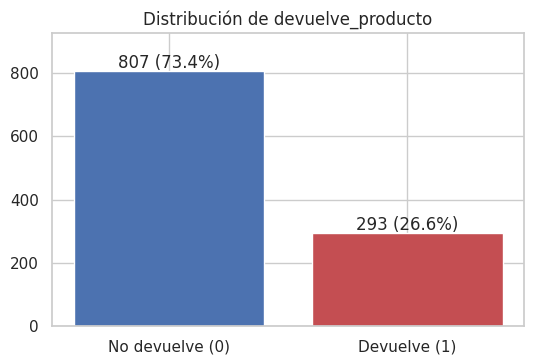

Pedidos: 1100 | devoluciones: 293 | tasa: 0.2664
Exactitud de predecir siempre 'no devuelve': 0.7336


In [6]:
# ============================================================
# 2.6.1 Distribución de la variable objetivo
# El EDA se hace sobre una copia sin duplicados para no contar dos
# veces el mismo pedido. Los nulos no se imputan aquí.
# ============================================================
eda = df.drop_duplicates().copy()

NUMERICAS = ['precio_producto_cop', 'descuento_pct', 'dias_entrega',
             'calificacion_producto', 'num_resenas_producto',
             'antiguedad_cliente_meses', 'compras_12m',
             'devoluciones_previas_12m', 'compatibilidad_expectativa_1_10']
BINARIAS  = ['envio_express', 'descripcion_completa']

vc = eda[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.bar(['No devuelve (0)', 'Devuelve (1)'], vc.values, color=['#4C72B0', '#C44E52'])
for i, v in enumerate(vc.values):
    ax.text(i, v + 10, f'{v} ({v/len(eda)*100:.1f}%)', ha='center')
ax.set_ylim(0, vc.max() * 1.15)
ax.set_title('Distribución de devuelve_producto')
plt.tight_layout(); plt.show()

print(f"Pedidos: {len(eda)} | devoluciones: {vc[1]} | tasa: {eda[TARGET].mean():.4f}")
print(f"Exactitud de predecir siempre 'no devuelve': {1 - eda[TARGET].mean():.4f}")

Hay 293 devoluciones en 1.100 pedidos (26,64%). Un modelo que siempre prediga "no devuelve" acertaría el 73,36% de las veces, así que la **exactitud no sirve** para evaluar este problema. Se usarán ROC-AUC para elegir el modelo, y recall, precisión y F1 para elegir el umbral.

La proporción 73/27 no es extrema, por lo que no se requieren técnicas de balanceo (que además están fuera del alcance del curso). La partición y la validación se estratifican para mantener esa proporción.

,variable,media_no_dev,media_dev,diferencia,r_con_objetivo
0,compatibilidad_expectativa_1_10,8.15,7.61,-0.54,-0.168
1,calificacion_producto,4.34,4.21,-0.13,-0.138
2,dias_entrega,4.34,5.01,0.66,0.119
3,devoluciones_previas_12m,0.98,1.25,0.27,0.116
4,precio_producto_cop,255734.63,221956.90,-33777.73,-0.060
5,antiguedad_cliente_meses,37.17,38.80,1.63,0.034
6,compras_12m,7.53,7.34,-0.19,-0.031
7,descuento_pct,15.57,16.15,0.58,0.029
8,num_resenas_producto,89.07,90.47,1.40,0.006


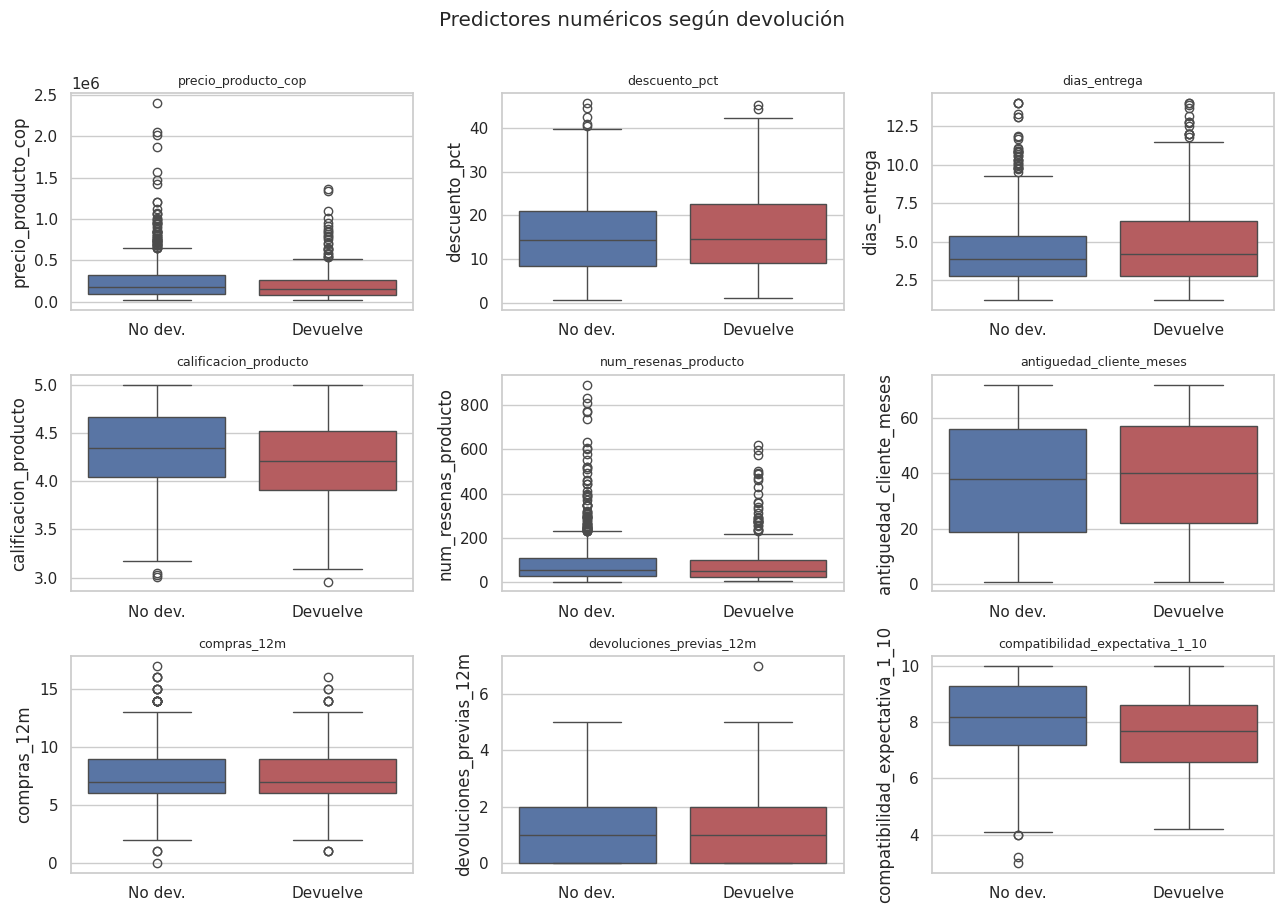

In [7]:
# ============================================================
# 2.6.2 Relación de los predictores numéricos con el objetivo
# Se comparan medias por clase y la correlación de cada variable con
# el objetivo 0/1 (correlación de Pearson, llamada punto-biserial
# cuando una de las variables es binaria).
# ============================================================
filas = []
for c in NUMERICAS:
    m0 = eda.loc[eda[TARGET] == 0, c].mean()
    m1 = eda.loc[eda[TARGET] == 1, c].mean()
    r  = eda[[c, TARGET]].dropna().corr().iloc[0, 1]
    filas.append({'variable': c, 'media_no_dev': round(m0, 2), 'media_dev': round(m1, 2),
                  'diferencia': round(m1 - m0, 2), 'r_con_objetivo': round(r, 3)})
tabla_num = pd.DataFrame(filas).sort_values('r_con_objetivo', key=abs, ascending=False)
display(tabla_num.reset_index(drop=True))

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for axi, c in zip(axes.ravel(), NUMERICAS):
    sns.boxplot(data=eda, x=TARGET, y=c, ax=axi, hue=TARGET,
                palette=['#4C72B0', '#C44E52'], legend=False)
    axi.set_xticks([0, 1]); axi.set_xticklabels(['No dev.', 'Devuelve'])
    axi.set_xlabel(''); axi.set_title(c, fontsize=9)
plt.suptitle('Predictores numéricos según devolución', y=1.01)
plt.tight_layout(); plt.show()

Las variables con mayor relación con la devolución son:

| Variable | Relación con la devolución | r |
|---|---|---|
| `compatibilidad_expectativa_1_10` | Menor compatibilidad (7,61 vs 8,15) | −0,168 |
| `calificacion_producto` | Peor calificación | −0,138 |
| `dias_entrega` | Más días de entrega (5,01 vs 4,34) | 0,119 |
| `devoluciones_previas_12m` | Más devoluciones previas | 0,116 |

`descuento_pct`, `num_resenas_producto`, `compras_12m` y `antiguedad_cliente_meses` tienen |r| < 0,04: en el análisis bivariado casi no se relacionan con la devolución.

Todas las correlaciones son débiles. Esto anticipa que ningún predictor por sí solo separa bien las clases y que la capacidad predictiva del modelo será moderada.

--- categoria_producto


,n,tasa_devolucion
categoria_producto,,
belleza,172,0.2849
deporte,194,0.2990
hogar,246,0.2114
moda,267,0.3333
tecnologia,221,0.2036


--- metodo_pago


,n,tasa_devolucion
metodo_pago,,
billetera,228,0.2588
contraentrega,134,0.2910
pse,315,0.2444
tarjeta,423,0.2790


--- envio_express


,n,tasa_devolucion
envio_express,,
0,776,0.2848
1,324,0.2222


--- descripcion_completa


,n,tasa_devolucion
descripcion_completa,,
0,172,0.3547
1,928,0.2500


,variable,tasa_min,tasa_max,brecha_pp
0,categoria_producto,0.2036,0.3333,13.0
1,descripcion_completa,0.2500,0.3547,10.5
2,envio_express,0.2222,0.2848,6.3
3,metodo_pago,0.2444,0.2910,4.7


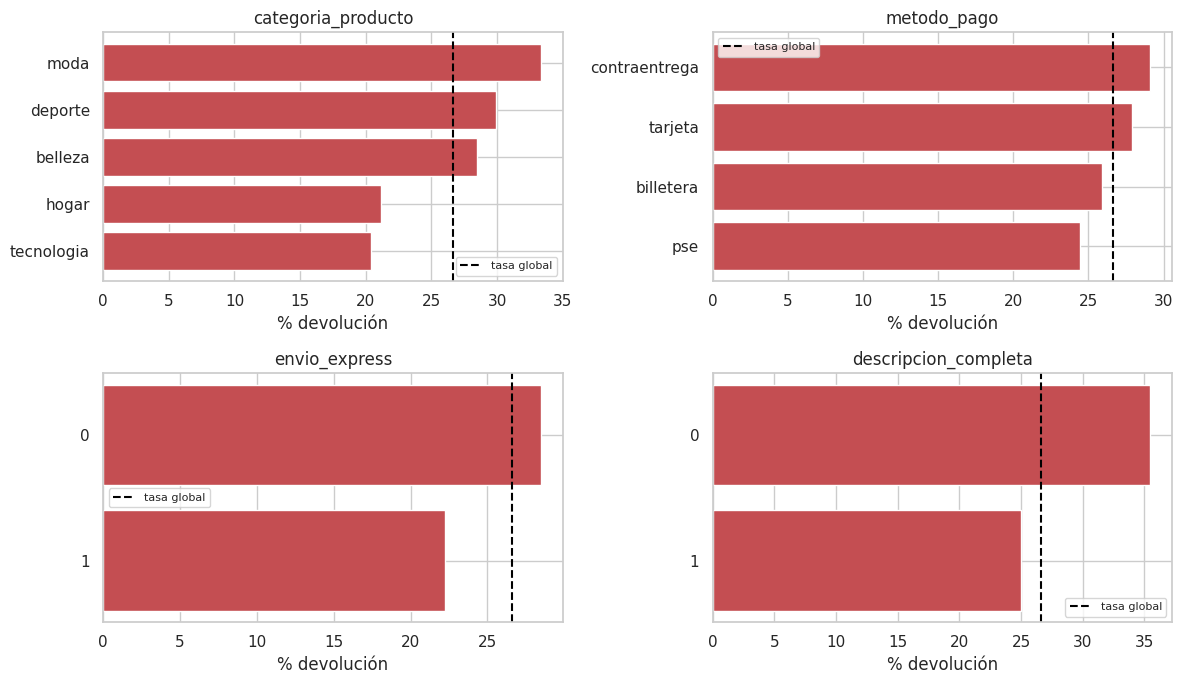

In [8]:
# ============================================================
# 2.6.3 Diferencias entre categorías: tasa de devolución por nivel
# ============================================================
filas = []
for c in CATEGORICAS + BINARIAS:
    g = eda.groupby(c)[TARGET].agg(['count', 'mean'])
    print(f"--- {c}")
    display(g.rename(columns={'count': 'n', 'mean': 'tasa_devolucion'}).round(4))
    filas.append({'variable': c, 'tasa_min': round(g['mean'].min(), 4),
                  'tasa_max': round(g['mean'].max(), 4),
                  'brecha_pp': round((g['mean'].max() - g['mean'].min()) * 100, 1)})
display(pd.DataFrame(filas).sort_values('brecha_pp', ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for axi, c in zip(axes.ravel(), CATEGORICAS + BINARIAS):
    g = eda.groupby(c)[TARGET].mean().sort_values()
    axi.barh(g.index.astype(str), g.values * 100, color='#C44E52')
    axi.axvline(eda[TARGET].mean() * 100, ls='--', c='black', label='tasa global')
    axi.set_xlabel('% devolución'); axi.set_title(c); axi.legend(fontsize=8)
plt.tight_layout(); plt.show()

- **Categoría:** moda tiene la tasa más alta (33,3%) y tecnología la más baja (20,4%), una brecha de 13 puntos.
- **Ficha del producto:** las fichas incompletas se devuelven más (35,5% vs 25,0%).
- **Envío express:** se asocia con menos devoluciones (22,2% vs 28,5%).
- **Método de pago:** las tasas van de 24,4% a 29,1%, la diferencia más pequeña de las cuatro.

Las categóricas se codifican con one-hot para que el modelo pueda estimar un efecto por nivel.

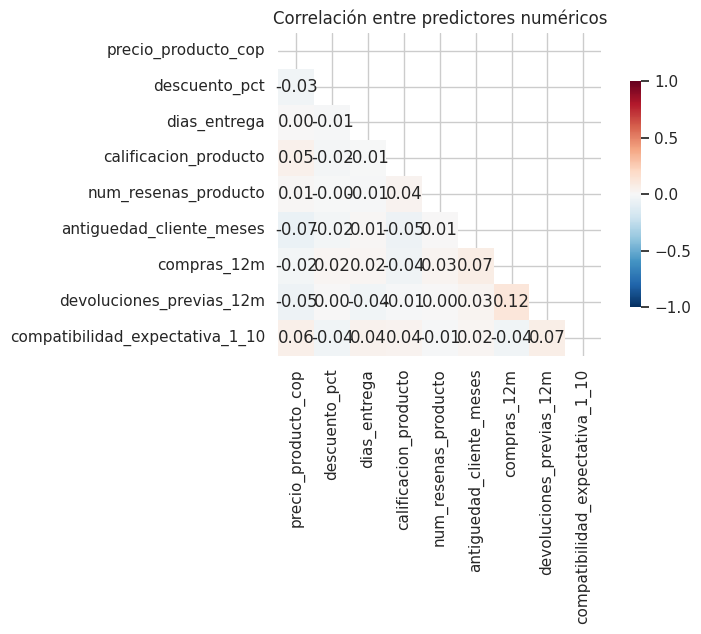

Pares con mayor correlación absoluta:
devoluciones_previas_12m         compras_12m                 0.121
compras_12m                      antiguedad_cliente_meses    0.073
compatibilidad_expectativa_1_10  devoluciones_previas_12m    0.069
antiguedad_cliente_meses         precio_producto_cop        -0.068
compatibilidad_expectativa_1_10  precio_producto_cop         0.062


In [9]:
# ============================================================
# 2.6.4 Correlación entre predictores numéricos
# ============================================================
corr = eda[NUMERICAS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .7})
plt.title('Correlación entre predictores numéricos')
plt.tight_layout(); plt.show()

pares = corr.where(~mask).stack().sort_values(key=abs, ascending=False)
print("Pares con mayor correlación absoluta:")
print(pares.head(5).round(3).to_string())

La mayor correlación entre predictores es 0,121 (`devoluciones_previas_12m` con `compras_12m`), es decir, **no hay multicolinealidad**. Esto favorece a la regresión logística: cada coeficiente se puede interpretar como el efecto propio de su variable.

--- dias_entrega


,n,tasa_devolucion
dias_entrega,,
"(0, 3]",348,0.2471
"(3, 4]",217,0.2488
"(4, 5]",162,0.2099
"(5, 6]",126,0.3016
"(6, 8]",124,0.2823
"(8, 20]",105,0.4190


--- compatibilidad_expectativa_1_10


,n,tasa_devolucion
compatibilidad_expectativa_1_10,,
"(0, 6]",95,0.4947
"(6, 7]",167,0.2934
"(7, 8]",277,0.2744
"(8, 9]",249,0.2570
"(9, 10]",294,0.1735


--- devoluciones_previas_12m


...

,n,tasa_devolucion
calificacion_producto,,
"(0.0, 4.0]",266,0.3346
"(4.0, 4.2]",174,0.3046
"(4.2, 4.4]",196,0.2704
"(4.4, 4.6]",163,0.2699
"(4.6, 5.1]",283,0.1802


--- precio_producto_cop


,n,tasa_devolucion
precio_producto_cop,,
"(0, 100000]",307,0.2997
"(100000, 200000]",323,0.2724
"(200000, 400000]",284,0.2500
"(400000, 3000000]",186,0.2258


--- descuento_pct


,n,tasa_devolucion
descuento_pct,,
"(0, 10]",329,0.2675
"(10, 20]",449,0.2472
"(20, 30]",246,0.2886
"(30, 50]",76,0.3026


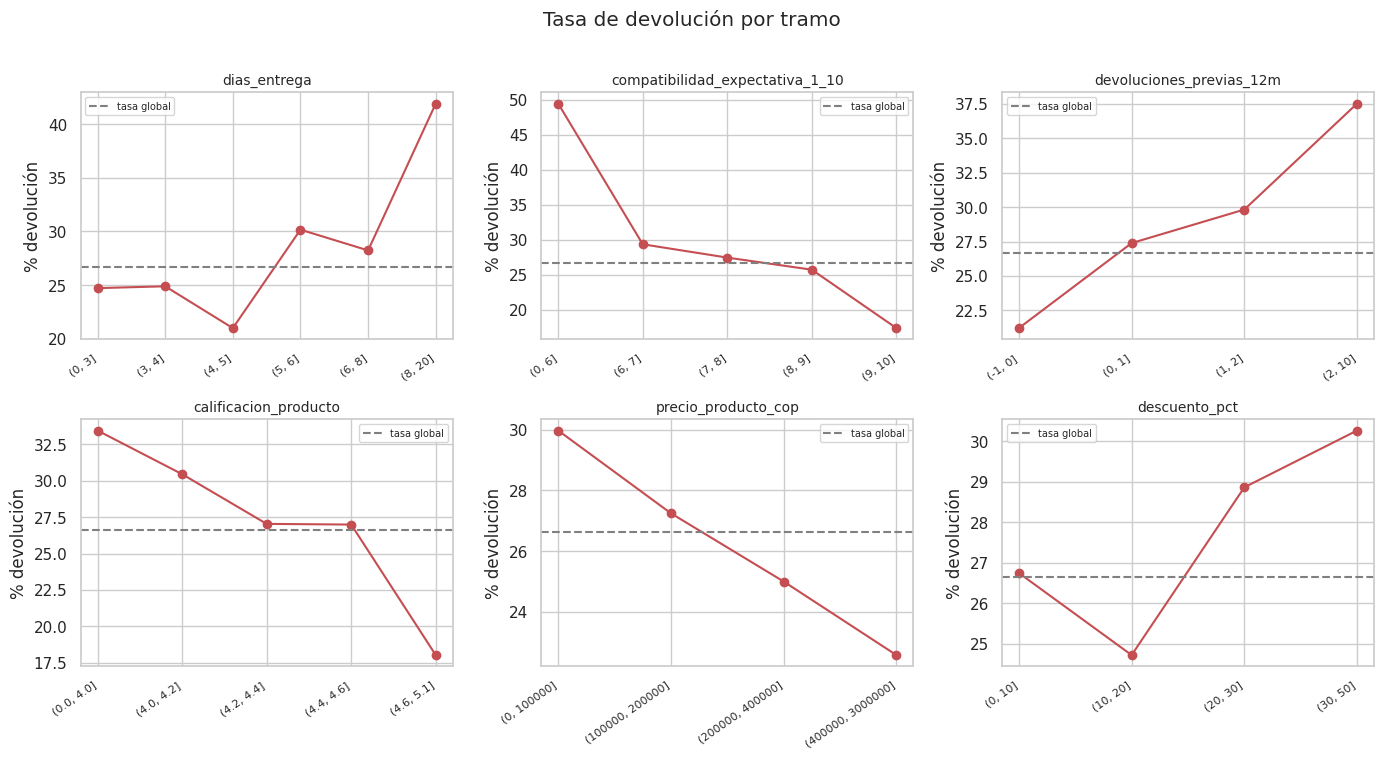

In [10]:
# ============================================================
# 2.6.5 Tasa de devolución por tramos: relaciones no lineales y umbrales
# ============================================================
CORTES = {
    'dias_entrega':                    [0, 3, 4, 5, 6, 8, 20],
    'compatibilidad_expectativa_1_10': [0, 6, 7, 8, 9, 10],
    'devoluciones_previas_12m':        [-1, 0, 1, 2, 10],
    'calificacion_producto':           [0, 4.0, 4.2, 4.4, 4.6, 5.1],
    'precio_producto_cop':             [0, 100_000, 200_000, 400_000, 3_000_000],
    'descuento_pct':                   [0, 10, 20, 30, 50],
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for axi, (v, bins) in zip(axes.ravel(), CORTES.items()):
    g = eda.groupby(pd.cut(eda[v], bins=bins), observed=True)[TARGET].agg(['count', 'mean'])
    axi.plot(range(len(g)), g['mean'] * 100, 'o-', color='#C44E52')
    axi.axhline(eda[TARGET].mean() * 100, ls='--', c='gray', label='tasa global')
    axi.set_xticks(range(len(g)))
    axi.set_xticklabels([str(i) for i in g.index], rotation=35, ha='right', fontsize=8)
    axi.set_title(v, fontsize=10); axi.set_ylabel('% devolución'); axi.legend(fontsize=7)
    print(f"--- {v}")
    display(g.rename(columns={'count': 'n', 'mean': 'tasa_devolucion'}).round(4))
plt.suptitle('Tasa de devolución por tramo', y=1.01)
plt.tight_layout(); plt.show()

**Hallazgo principal para elegir el modelo:**
- `dias_entrega` **no es lineal**: la tasa se mantiene entre 21% y 25% hasta los 5 días, sube a cerca de 30% entre 5 y 8 días y llega a 41,9% con más de 8 días. Hay un umbral más que una pendiente constante.
- `compatibilidad_expectativa_1_10` (49,5% → 17,4%), `calificacion_producto` (33,5% → 18,0%) y `devoluciones_previas_12m` (21,2% → 37,5%) tienen relaciones monótonas, que una regresión logística captura bien.
- `descuento_pct` no muestra un patrón claro (entre 24,7% y 30,3%).

Por eso se comparan dos modelos: una **regresión logística**, adecuada para las relaciones monótonas e interpretable, y un **árbol de decisión**, capaz de captar el umbral de `dias_entrega` sin transformar variables.

In [11]:
# ============================================================
# 2.7 Identificación de variables con riesgo de fuga
# ============================================================
auditoria_fuga = pd.DataFrame([
    ('satisfaccion_postcompra_1_10', 'Objetivo de la Ruta A. El enunciado prohíbe usarla como predictor en la Ruta B.', 'Excluir'),
    ('id_pedido', 'Identificador sin significado; el enunciado prohíbe usarlo.', 'Excluir'),
    ('dias_entrega', 'Se conoce al completarse la entrega, antes de que el cliente decida devolver.', 'Conservar'),
    ('compatibilidad_expectativa_1_10', 'Se conoce cuando el cliente recibe el producto, antes de la devolución.', 'Conservar'),
    ('devoluciones_previas_12m', 'Historial anterior al pedido; no incluye la devolución que se predice.', 'Conservar'),
], columns=['variable', 'análisis', 'decisión'])
display(auditoria_fuga)

r_obj = eda[[TARGET] + OTRO_OBJETIVO].corr().iloc[0, 1]
print(f"Correlación entre los dos objetivos: r = {r_obj:.3f}")

,variable,análisis,decisión
0,satisfaccion_postcompra_1_10,Objetivo de la Ruta A. El enunciado prohíbe usarla como predictor en la Ruta B.,Excluir
1,id_pedido,Identificador sin significado; el enunciado prohíbe usarlo.,Excluir
2,dias_entrega,"Se conoce al completarse la entrega, antes de que el cliente decida devolver.",Conservar
3,compatibilidad_expectativa_1_10,"Se conoce cuando el cliente recibe el producto, antes de la devolución.",Conservar
4,devoluciones_previas_12m,Historial anterior al pedido; no incluye la devolución que se predice.,Conservar


Correlación entre los dos objetivos: r = -0.169


**Control de fuga:** se excluyen `satisfaccion_postcompra_1_10` (objetivo de la Ruta A, prohibido por el enunciado) e `id_pedido` (identificador). La exclusión no depende de qué tan correlacionada esté la variable (r = −0,169), sino de la regla del enunciado.

También se revisaron `dias_entrega`, `compatibilidad_expectativa_1_10` y `devoluciones_previas_12m`: se conservan porque se conocen antes de que ocurra la devolución, siempre que el modelo se use en el momento definido en la Fase 1 (después de la entrega).

In [12]:
# ============================================================
# 2.8 Diagnóstico de la Ruta A (satisfacción) para justificar la ruta elegida
# ============================================================
from sklearn.linear_model import LinearRegression

sat = eda['satisfaccion_postcompra_1_10']
print(f"Media: {sat.mean():.3f} | asimetría: {sat.skew():.3f}")
print(f"Rango: [{sat.min():.2f}, {sat.max():.2f}]")
print(f"% exactamente en 10 : {(sat == 10).mean()*100:.2f}% ({int((sat == 10).sum())} pedidos)")
print(f"% en el rango [9,10]: {(sat >= 9).mean()*100:.2f}%\n")

# Correlación de cada predictor numérico con la satisfacción
r_sat = (eda[NUMERICAS + ['satisfaccion_postcompra_1_10']].corr()['satisfaccion_postcompra_1_10']
         .drop('satisfaccion_postcompra_1_10').sort_values(key=abs, ascending=False).round(3))
display(r_sat.to_frame('r_con_satisfaccion'))

# R² descriptivo: regresión simple (solo dias_entrega) vs. múltiple (9 numéricas).
# Se usan solo filas completas; es un diagnóstico, no un modelo evaluado.
completas = eda[NUMERICAS + ['satisfaccion_postcompra_1_10']].dropna()
y_sat = completas['satisfaccion_postcompra_1_10']
r2_simple = LinearRegression().fit(completas[['dias_entrega']], y_sat).score(completas[['dias_entrega']], y_sat)
r2_multi  = LinearRegression().fit(completas[NUMERICAS], y_sat).score(completas[NUMERICAS], y_sat)
print(f"R² satisfacción ~ dias_entrega       : {r2_simple:.3f}")
print(f"R² satisfacción ~ 9 predictores      : {r2_multi:.3f}")
print(f"Aporte de los otros 8 predictores    : {(r2_multi - r2_simple)*100:+.1f} pp")

Media: 8.897 | asimetría: -0.923
Rango: [3.70, 10.00]
% exactamente en 10 : 24.73% (272 pedidos)
% en el rango [9,10]: 52.91%



,r_con_satisfaccion
dias_entrega,-0.520
calificacion_producto,0.195
compatibilidad_expectativa_1_10,0.123
devoluciones_previas_12m,-0.114
compras_12m,-0.071
antiguedad_cliente_meses,-0.025
descuento_pct,0.017
num_resenas_producto,0.017
precio_producto_cop,0.014


R² satisfacción ~ dias_entrega       : 0.287
R² satisfacción ~ 9 predictores      : 0.370
Aporte de los otros 8 predictores    : +8.3 pp


**Diagnóstico de la Ruta A:**
1. **Efecto techo:** el 24,73% de los pedidos tiene satisfacción exactamente 10 y el 52,91% está entre 9 y 10. Una regresión lineal podría predecir valores mayores que 10 y sus residuales no serían simétricos.
2. **Un predictor dominante:** `dias_entrega` explica por sí sola el 28,7% de la variación (r = −0,520). Los otros ocho predictores solo agregan 8,3 puntos (R² = 0,370).
3. **Objetivos distintos:** la correlación entre satisfacción y devolución es −0,169. Son fenómenos relacionados pero diferentes.

**Respuesta descriptiva a la parte de satisfacción de la pregunta guía:** el tiempo de entrega es, con diferencia, el factor más asociado a la satisfacción, seguido de lejos por la calificación del producto (r = 0,195) y la compatibilidad con la expectativa (r = 0,123).

## Fase 3 — Preparación de los datos
Orden de trabajo: depurar → separar X e y → particionar → definir el preprocesamiento. Ningún cálculo que dependa de los datos (medianas, medias, desviaciones) se ajusta antes de la partición.

In [13]:
# ============================================================
# 3.1 Eliminación de duplicados exactos (decisión de la sección 2.4)
# ============================================================
datos = df.drop_duplicates().reset_index(drop=True)
print(f"Antes  : {len(df)} filas | tasa de devolución {df[TARGET].mean():.4f}")
print(f"Después: {len(datos)} filas | tasa de devolución {datos[TARGET].mean():.4f}")
assert datos['id_pedido'].is_unique, "Persisten id_pedido repetidos"
print("id_pedido es único tras la depuración")

Antes  : 1108 filas | tasa de devolución 0.2681
Después: 1100 filas | tasa de devolución 0.2664
id_pedido es único tras la depuración


In [14]:
# ============================================================
# 3.2 Construcción de X e y con exclusión explícita de fuga
# ============================================================
EXCLUIDAS = [TARGET] + OTRO_OBJETIVO + IDENTIF
X = datos.drop(columns=EXCLUIDAS)
y = datos[TARGET]

# Si alguna columna excluida llegara a X, el notebook se detiene aquí
assert not set(EXCLUIDAS) & set(X.columns), "FUGA: columna prohibida en X"

CATEGORICAS_X = ['categoria_producto', 'metodo_pago']
BINARIAS_X    = ['envio_express', 'descripcion_completa']
assert sorted(NUMERICAS + CATEGORICAS_X + BINARIAS_X) == sorted(X.columns)

print(f"Excluidas de X: {EXCLUIDAS}")
print(f"X: {X.shape[0]} filas x {X.shape[1]} predictores")
print(f"y: {y.sum()} devoluciones ({y.mean():.4f})")

Excluidas de X: ['devuelve_producto', 'satisfaccion_postcompra_1_10', 'id_pedido']
X: 1100 filas x 13 predictores
y: 293 devoluciones (0.2664)


El `assert` detiene el notebook si alguna columna prohibida llega a X, de modo que el control de fuga queda verificado en el código y no solo en el texto.

In [15]:
# ============================================================
# 3.3 Partición entrenamiento / prueba (antes de cualquier ajuste)
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

display(pd.DataFrame({
    'conjunto': ['completo', 'entrenamiento', 'prueba'],
    'n': [len(y), len(y_train), len(y_test)],
    'devoluciones': [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
    'tasa': [round(y.mean(), 4), round(y_train.mean(), 4), round(y_test.mean(), 4)]}))

,conjunto,n,devoluciones,tasa
0,completo,1100,293,0.2664
1,entrenamiento,825,220,0.2667
2,prueba,275,73,0.2655


Partición 75/25 estratificada con semilla 42: 825 pedidos de entrenamiento (220 devoluciones) y 275 de prueba (73 devoluciones). Se usa 25% en lugar de 20% para que la prueba tenga más devoluciones y el recall sea más estable. **El conjunto de prueba no se vuelve a usar hasta la sección 5.2.**

In [16]:
# ============================================================
# 3.4 Preprocesamiento (se ajusta dentro del Pipeline, solo con train)
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def construir_preprocesador():
    """Numéricas: mediana + estandarización. Categóricas: moda + one-hot.
    Binarias: sin cambios."""
    numericas = Pipeline([('imputar', SimpleImputer(strategy='median')),
                          ('estandarizar', StandardScaler())])
    categoricas = Pipeline([('imputar', SimpleImputer(strategy='most_frequent')),
                            ('codificar', OneHotEncoder(drop='first', handle_unknown='ignore',
                                                        sparse_output=False))])
    return ColumnTransformer([('num', numericas, NUMERICAS),
                              ('cat', categoricas, CATEGORICAS_X),
                              ('bin', 'passthrough', BINARIAS_X)],
                             verbose_feature_names_out=False)

| Decisión | Justificación |
|---|---|
| Imputación por mediana (numéricas) | Robusta a asimetría; se calcula solo con train (sección 2.5) |
| Imputación por moda (categóricas) | No hay nulos, pero protege el pipeline ante datos nuevos |
| Estandarización de numéricas | La regularización L1/L2 penaliza el tamaño de los coeficientes; sin escala común, la penalización depende de las unidades. En el árbol no cambia los cortes |
| Binarias sin escalar | Ya están en 0/1 y así se interpretan directamente |
| One-hot con `drop='first'` | Evita la colinealidad perfecta entre variables dummy |
| `handle_unknown='ignore'` | Evita errores si aparece una categoría nueva |

Todo el preprocesamiento vive dentro de un `Pipeline`. Así, en cada pliegue de validación cruzada y en el ajuste final, `fit` solo ve los datos de entrenamiento correspondientes.

In [17]:
# ============================================================
# 3.5 Verificación: el preprocesamiento solo aprende de train
# ============================================================
prep = construir_preprocesador()
A = prep.fit_transform(X_train)   # ajuste con train
B = prep.transform(X_test)        # test solo se transforma
nombres = list(prep.get_feature_names_out())
print(f"{A.shape[1]} variables tras el preprocesamiento: {nombres}\n")
print(f"Nulos restantes (train + test): {int(np.isnan(A).sum() + np.isnan(B).sum())}")

k = len(NUMERICAS)   # las numéricas son las primeras columnas
print(f"Train: media máx. |{np.abs(A[:, :k].mean(axis=0)).max():.4f}| (0 por construcción)")
print(f"Test : media máx. |{np.abs(B[:, :k].mean(axis=0)).max():.4f}| (distinta de 0: el escalador no vio el test)")

18 variables tras el preprocesamiento: ['precio_producto_cop', 'descuento_pct', 'dias_entrega', 'calificacion_producto', 'num_resenas_producto', 'antiguedad_cliente_meses', 'compras_12m', 'devoluciones_previas_12m', 'compatibilidad_expectativa_1_10', 'categoria_producto_deporte', 'categoria_producto_hogar', 'categoria_producto_moda', 'categoria_producto_tecnologia', 'metodo_pago_contraentrega', 'metodo_pago_pse', 'metodo_pago_tarjeta', 'envio_express', 'descripcion_completa']

Nulos restantes (train + test): 0
Train: media máx. |0.0000| (0 por construcción)
Test : media máx. |0.1829| (distinta de 0: el escalador no vio el test)


Tras el preprocesamiento quedan 18 variables: 9 numéricas, 4 dummies de categoría, 3 de método de pago y 2 binarias. En train la media de las numéricas es 0 por construcción; en test no lo es (máx. 0,18), lo que confirma que el escalador se ajustó sin ver el conjunto de prueba.

In [18]:
# ============================================================
# 3.6 Esquema de validación cruzada
# ============================================================
from sklearn.model_selection import StratifiedKFold

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for i, (tr, va) in enumerate(CV.split(X_train, y_train), 1):
    print(f"Pliegue {i}: entrena {len(tr)} | valida {len(va)} | tasa validación {y_train.iloc[va].mean():.4f}")

Pliegue 1: entrena 660 | valida 165 | tasa validación 0.2667
Pliegue 2: entrena 660 | valida 165 | tasa validación 0.2667
Pliegue 3: entrena 660 | valida 165 | tasa validación 0.2667
Pliegue 4: entrena 660 | valida 165 | tasa validación 0.2667
Pliegue 5: entrena 660 | valida 165 | tasa validación 0.2667


## Fase 4 — Modelado

### 4.1 Modelos seleccionados
El enunciado no pide probar todos los modelos, sino justificar la elección. A partir del EDA se comparan dos:

| Modelo | Por qué |
|---|---|
| **Regresión logística regularizada** | Objetivo binario; relaciones mayormente monótonas; sin multicolinealidad; sus coeficientes se traducen en odds ratios, que responden directamente "qué factores explican" la devolución. Requiere estandarizar por la regularización |
| **Árbol de decisión** | Puede captar el umbral de `dias_entrega` (> 8 días) sin transformar variables. No requiere estandarización |

Métrica de selección: **ROC-AUC** en validación cruzada estratificada de 5 pliegues, solo sobre train.

,C,AUC_train,AUC_validacion
0,0.0001,0.6787,0.6511
1,0.0010,0.6841,0.6544
2,0.0100,0.6956,0.6643
3,0.1000,0.7025,0.6653
4,1.0000,0.7028,0.6636
5,10.0000,0.7029,0.6634
6,100.0000,0.7029,0.6633
7,1000.0000,0.7029,0.6633
8,10000.0000,0.7029,0.6633


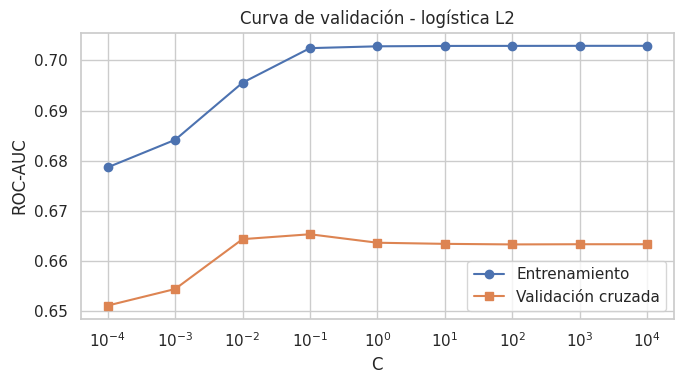

In [19]:
# ============================================================
# 4.2 Curva de validación de C (regresión logística, L2)
# C es el inverso de la intensidad de regularización.
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import validation_curve

def crear_logistica(C=1.0, l1_ratio=0.0):
    """Pipeline de la logística. l1_ratio=0 -> L2 (Ridge), l1_ratio=1 -> L1 (Lasso)."""
    return Pipeline([('prep', construir_preprocesador()),
                     ('m', LogisticRegression(C=C, l1_ratio=l1_ratio, solver='liblinear',
                                              max_iter=5000, random_state=RANDOM_STATE))])

valores_C = np.logspace(-4, 4, 9)
tr_sc, va_sc = validation_curve(crear_logistica(), X_train, y_train,
                                param_name='m__C', param_range=valores_C,
                                cv=CV, scoring='roc_auc', n_jobs=-1)

curva = pd.DataFrame({'C': valores_C, 'AUC_train': tr_sc.mean(axis=1).round(4),
                      'AUC_validacion': va_sc.mean(axis=1).round(4)})
display(curva)

plt.figure(figsize=(7, 4))
plt.semilogx(valores_C, tr_sc.mean(axis=1), 'o-', label='Entrenamiento')
plt.semilogx(valores_C, va_sc.mean(axis=1), 's-', label='Validación cruzada')
plt.xlabel('C'); plt.ylabel('ROC-AUC'); plt.title('Curva de validación - logística L2')
plt.legend(); plt.tight_layout(); plt.show()

**Curva de validación:** con regularización muy fuerte (C = 0,0001) el AUC de validación baja a 0,651, una señal de subajuste. A partir de C = 0,1 el AUC de validación se estabiliza alrededor de 0,663-0,665 y el de entrenamiento alrededor de 0,703. La brecha es de unos 4 puntos y no crece al aumentar C, así que no aparece sobreajuste: con 18 variables y 825 pedidos, el modelo lineal no tiene capacidad para memorizar.

In [20]:
# ============================================================
# 4.3 Búsqueda de hiperparámetros de la logística: C y tipo de penalización
# ============================================================
from sklearn.model_selection import GridSearchCV

grid_log = GridSearchCV(crear_logistica(),
                        {'m__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
                         'm__l1_ratio': [0.0, 1.0]},
                        scoring='roc_auc', cv=CV, n_jobs=-1, return_train_score=True)
grid_log.fit(X_train, y_train)

res_log = pd.DataFrame(grid_log.cv_results_)[
    ['param_m__C', 'param_m__l1_ratio', 'mean_train_score', 'mean_test_score', 'std_test_score']]
res_log.columns = ['C', 'l1_ratio', 'AUC_train', 'AUC_validacion', 'sd_validacion']
display(res_log.sort_values('AUC_validacion', ascending=False).round(4).head(8).reset_index(drop=True))

MEJOR_C  = grid_log.best_params_['m__C']
MEJOR_L1 = grid_log.best_params_['m__l1_ratio']
print(f"Mejor combinación: C = {MEJOR_C}, penalización = {'L1' if MEJOR_L1 == 1 else 'L2'} "
      f"| AUC validación = {grid_log.best_score_:.4f}")

,C,l1_ratio,AUC_train,AUC_validacion,sd_validacion
0,0.50,1.0,0.7024,0.6669,0.0407
1,0.10,0.0,0.7025,0.6653,0.0395
2,1.00,1.0,0.7029,0.6652,0.0413
3,0.05,0.0,0.7014,0.6650,0.0391
4,0.01,0.0,0.6956,0.6643,0.0364
5,1.00,0.0,0.7028,0.6636,0.0415
6,5.00,0.0,0.7029,0.6634,0.0419
7,10.00,1.0,0.7029,0.6634,0.0416


Mejor combinación: C = 0.5, penalización = L1 | AUC validación = 0.6669


La mejor combinación es **C = 0,5 con penalización L1** (AUC de validación 0,6669, sd 0,0407). Las primeras combinaciones difieren en menos de 0,003, muy por debajo de la desviación entre pliegues, así que en desempeño son equivalentes. L1 tiene la ventaja de poder llevar a cero los coeficientes de variables sin aporte.

,criterio,max_depth,AUC_train,AUC_validacion,sd_validacion
0,entropy,3,0.6569,0.5762,0.0348
1,gini,3,0.6459,0.5727,0.0369
2,entropy,2,0.6208,0.5691,0.0325
3,gini,2,0.6158,0.5677,0.0352
4,entropy,4,0.7008,0.5640,0.0469
5,gini,1,0.5784,0.5622,0.0432
6,entropy,5,0.7455,0.5618,0.0660
7,gini,8,0.8664,0.5486,0.0438


Mejor árbol: {'m__criterion': 'entropy', 'm__max_depth': 3} | AUC validación = 0.5762


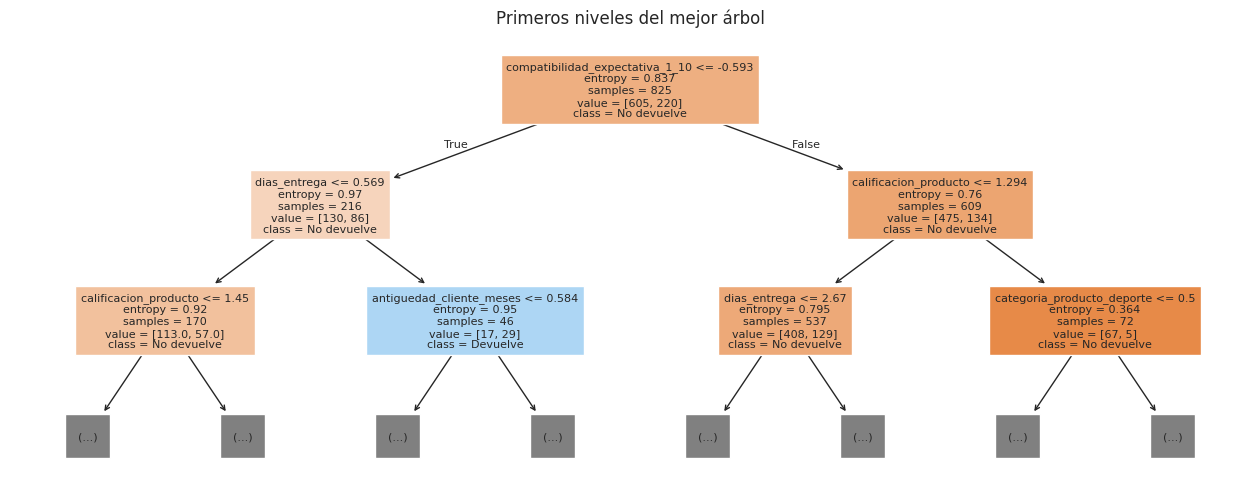

In [21]:
# ============================================================
# 4.4 Modelo de contraste: árbol de decisión
# ============================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree

pipe_arbol = Pipeline([('prep', construir_preprocesador()),
                       ('m', DecisionTreeClassifier(random_state=RANDOM_STATE))])
grid_arbol = GridSearchCV(pipe_arbol,
                          {'m__criterion': ['gini', 'entropy'],
                           'm__max_depth': [1, 2, 3, 4, 5, 6, 8]},
                          scoring='roc_auc', cv=CV, n_jobs=-1, return_train_score=True)
grid_arbol.fit(X_train, y_train)

res_arbol = pd.DataFrame(grid_arbol.cv_results_)[
    ['param_m__criterion', 'param_m__max_depth', 'mean_train_score', 'mean_test_score', 'std_test_score']]
res_arbol.columns = ['criterio', 'max_depth', 'AUC_train', 'AUC_validacion', 'sd_validacion']
display(res_arbol.sort_values('AUC_validacion', ascending=False).round(4).head(8).reset_index(drop=True))
print(f"Mejor árbol: {grid_arbol.best_params_} | AUC validación = {grid_arbol.best_score_:.4f}")

arbol = grid_arbol.best_estimator_
plt.figure(figsize=(16, 6))
plot_tree(arbol.named_steps['m'], max_depth=2, filled=True, fontsize=8,
          feature_names=arbol.named_steps['prep'].get_feature_names_out(),
          class_names=['No devuelve', 'Devuelve'])
plt.title('Primeros niveles del mejor árbol'); plt.show()

El mejor árbol usa entropía y profundidad 3, con AUC de validación de 0,576. Al aumentar la profundidad, el AUC de entrenamiento sube (0,866 con profundidad 8) mientras el de validación baja: el árbol sobreajusta rápidamente. Aunque su primer corte captura parte de la estructura, las reglas por umbrales no logran separar bien las clases cuando la señal está repartida en muchas variables débiles.

In [22]:
# ============================================================
# 4.5 Comparación y selección del modelo (solo validación cruzada)
# ============================================================
i_log, i_arb = grid_log.best_index_, grid_arbol.best_index_
comparacion = pd.DataFrame({
    'modelo': ['Regresión logística', 'Árbol de decisión'],
    'hiperparámetros': [f"C={MEJOR_C}, {'L1' if MEJOR_L1 == 1 else 'L2'}", str(grid_arbol.best_params_)],
    'AUC_train': [grid_log.cv_results_['mean_train_score'][i_log], grid_arbol.cv_results_['mean_train_score'][i_arb]],
    'AUC_validacion': [grid_log.best_score_, grid_arbol.best_score_],
    'sd_validacion': [grid_log.cv_results_['std_test_score'][i_log], grid_arbol.cv_results_['std_test_score'][i_arb]],
})
comparacion['brecha'] = comparacion['AUC_train'] - comparacion['AUC_validacion']
display(comparacion.round(4))

,modelo,hiperparámetros,AUC_train,AUC_validacion,sd_validacion,brecha
0,Regresión logística,"C=0.5, L1",0.7024,0.6669,0.0407,0.0355
1,Árbol de decisión,"{'m__criterion': 'entropy', 'm__max_depth': 3}",0.6569,0.5762,0.0348,0.0807


### 4.5 Decisión
Se elige la **regresión logística con L1 (C = 0,5)**:
- Mayor AUC de validación (0,667 frente a 0,576).
- Menor brecha entre entrenamiento y validación (0,036 frente a 0,081).
- Es interpretable mediante odds ratios, que es lo que pide la pregunta guía.

El umbral no lineal de `dias_entrega` no hizo que el árbol superara a la logística. Ese hallazgo se conserva como información de negocio (sección 6.4).

In [23]:
# ============================================================
# 4.6 Modelo final: regresión logística con los mejores hiperparámetros
# GridSearchCV ya lo reajustó sobre todo X_train (refit=True).
# ============================================================
modelo_final = grid_log.best_estimator_

nombres = modelo_final.named_steps['prep'].get_feature_names_out()
coefs   = modelo_final.named_steps['m'].coef_[0]
tabla_coef = pd.DataFrame({'variable': nombres, 'coeficiente': coefs.round(4),
                           'odds_ratio': np.exp(coefs).round(3)})
display(tabla_coef.reindex(tabla_coef['coeficiente'].abs().sort_values(ascending=False).index)
        .reset_index(drop=True))
print(f"Intercepto: {modelo_final.named_steps['m'].intercept_[0]:.4f}")
print(f"Coeficientes anulados por L1: {list(nombres[coefs == 0])}")

,variable,coeficiente,odds_ratio
0,compatibilidad_expectativa_1_10,-0.4443,0.641
1,categoria_producto_tecnologia,-0.4279,0.652
2,envio_express,-0.3932,0.675
3,descripcion_completa,-0.3898,0.677
4,categoria_producto_moda,0.3216,1.379
5,devoluciones_previas_12m,0.3209,1.378
6,categoria_producto_hogar,-0.2628,0.769
7,calificacion_producto,-0.2608,0.770
8,dias_entrega,0.2593,1.296
9,compras_12m,-0.1750,0.839


Intercepto: -0.5801
Coeficientes anulados por L1: ['categoria_producto_deporte', 'metodo_pago_tarjeta']


Los coeficientes están en unidades estandarizadas (por desviación estándar) y sirven para comparar la importancia relativa de las variables. Los más grandes en valor absoluto son compatibilidad con la expectativa, categoría tecnología, envío express, ficha completa, categoría moda y devoluciones previas. L1 anuló `categoria_producto_deporte` y `metodo_pago_tarjeta`, y dejó cerca de cero el resto del método de pago, el precio, el descuento, las reseñas y la antigüedad. Esto coincide con el EDA. La interpretación en unidades originales y con p-valores se hace en la sección 6.1.

## Fase 5 — Evaluación

### 5.1 Umbral de clasificación
El umbral de 0,5 no es obligatorio: es una regla de decisión que depende del costo de cada error.

- **Falso negativo:** una devolución que no se anticipa. Se pagan la logística inversa, la revisión y el margen perdido.
- **Falso positivo:** un contacto postentrega innecesario, cuyo costo es bajo.

**El falso negativo es el error más costoso**, así que conviene un umbral más bajo que 0,5. Como el umbral funciona como un hiperparámetro, se elige con probabilidades de **validación cruzada sobre train**, sin usar el conjunto de prueba.

AUC con probabilidades de validación: 0.6675



,umbral,marcados_pct,TP,FP,FN,TN,recall,precision,f1
0,0.15,81.1,199,470,21,135,0.9045,0.2975,0.4477
1,0.20,64.0,171,357,49,248,0.7773,0.3239,0.4572
2,0.25,48.1,147,250,73,355,0.6682,0.3703,0.4765
3,0.30,34.2,117,165,103,440,0.5318,0.4149,0.4661
4,0.35,23.2,85,106,135,499,0.3864,0.4450,0.4136
5,0.40,15.0,63,61,157,544,0.2864,0.5081,0.3663
6,0.45,10.4,50,36,170,569,0.2273,0.5814,0.3268
7,0.50,7.0,38,20,182,585,0.1727,0.6552,0.2734
8,0.55,3.8,22,9,198,596,0.1000,0.7097,0.1753
9,0.60,2.4,15,5,205,600,0.0682,0.7500,0.1250


Umbral elegido: 0.25


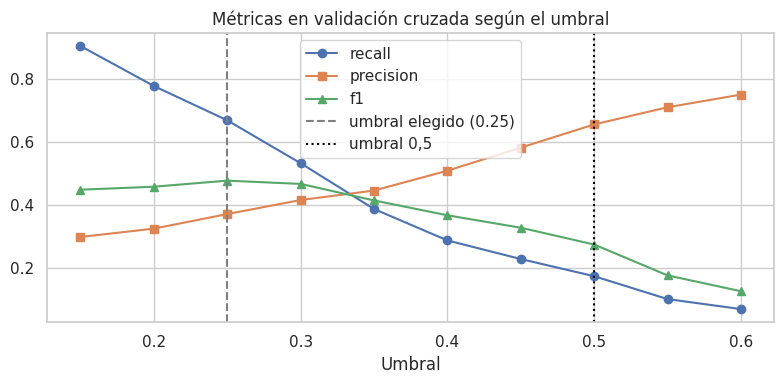

In [24]:
# ============================================================
# 5.1 Elección del umbral con probabilidades de validación cruzada
# Cada pedido de train recibe su probabilidad del modelo entrenado en
# los otros 4 pliegues. El conjunto de prueba no interviene.
# ============================================================
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

prob_val = np.zeros(len(y_train))
for tr, va in CV.split(X_train, y_train):
    m = crear_logistica(C=MEJOR_C, l1_ratio=MEJOR_L1)
    m.fit(X_train.iloc[tr], y_train.iloc[tr])
    prob_val[va] = m.predict_proba(X_train.iloc[va])[:, 1]
print(f"AUC con probabilidades de validación: {roc_auc_score(y_train, prob_val):.4f}\n")

def tabla_por_umbral(y_real, prob, umbrales):
    filas = []
    for u in umbrales:
        pred = (prob >= u).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_real, pred).ravel()
        filas.append({'umbral': u, 'marcados_pct': round(pred.mean() * 100, 1),
                      'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                      'recall': round(recall_score(y_real, pred, zero_division=0), 4),
                      'precision': round(precision_score(y_real, pred, zero_division=0), 4),
                      'f1': round(f1_score(y_real, pred, zero_division=0), 4)})
    return pd.DataFrame(filas)

UMBRALES = np.round(np.arange(0.15, 0.61, 0.05), 2)
tabla_val = tabla_por_umbral(y_train, prob_val, UMBRALES)
display(tabla_val)

# Regla definida antes de mirar el test: como el falso negativo es el
# error más costoso, se exige detectar al menos el 60% de las devoluciones
# y, entre los umbrales que lo cumplen, se toma el más alto (más precisión).
RECALL_MIN = 0.60
UMBRAL = float(tabla_val.loc[tabla_val['recall'] >= RECALL_MIN, 'umbral'].max())
print(f"Umbral elegido: {UMBRAL}")

plt.figure(figsize=(8, 4))
for col, mk in [('recall', 'o-'), ('precision', 's-'), ('f1', '^-')]:
    plt.plot(tabla_val['umbral'], tabla_val[col], mk, label=col)
plt.axvline(UMBRAL, ls='--', c='gray', label=f'umbral elegido ({UMBRAL})')
plt.axvline(0.5, ls=':', c='black', label='umbral 0,5')
plt.xlabel('Umbral'); plt.title('Métricas en validación cruzada según el umbral')
plt.legend(); plt.tight_layout(); plt.show()

Con umbral 0,5 solo se detecta el 17,3% de las devoluciones en validación. La regla fijada (recall ≥ 60% y, entre los umbrales que lo cumplen, el de mayor precisión) lleva a un **umbral de 0,25**: en validación detecta el 66,8% de las devoluciones con una precisión de 37,0%, marcando el 48,1% de los pedidos. El F1 máximo también está en 0,25 (0,4765).

,conjunto,AUC
0,Entrenamiento,0.6994
1,Validación cruzada,0.6669
2,Prueba,0.7150


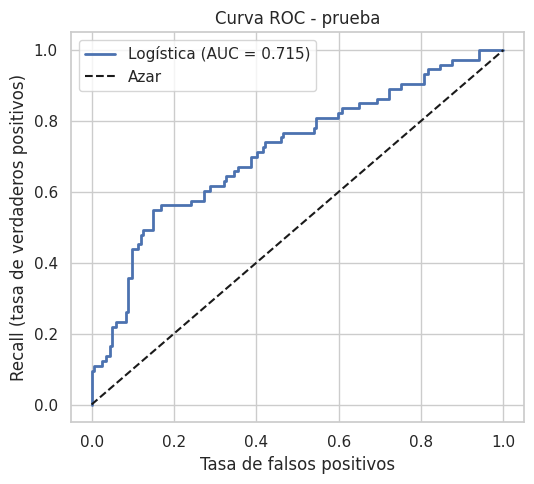

In [25]:
# ============================================================
# 5.2 Evaluación final en el conjunto de prueba (una sola vez)
# ============================================================
prob_train = modelo_final.predict_proba(X_train)[:, 1]
prob_test  = modelo_final.predict_proba(X_test)[:, 1]

auc_train = roc_auc_score(y_train, prob_train)
auc_cv    = grid_log.best_score_
auc_test  = roc_auc_score(y_test, prob_test)
display(pd.DataFrame({'conjunto': ['Entrenamiento', 'Validación cruzada', 'Prueba'],
                      'AUC': [round(auc_train, 4), round(auc_cv, 4), round(auc_test, 4)]}))

fpr, tpr, _ = roc_curve(y_test, prob_test)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, lw=2, label=f'Logística (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Recall (tasa de verdaderos positivos)')
plt.title('Curva ROC - prueba'); plt.legend(); plt.tight_layout(); plt.show()

| Conjunto | AUC |
|---|---|
| Entrenamiento (modelo ajustado con todo train) | 0,699 |
| Validación cruzada | 0,667 |
| Prueba | 0,715 |

El AUC de entrenamiento de esta tabla (0,699) es distinto del de la sección 4.5 (0,702) porque allí se promedia el AUC de entrenamiento de los 5 pliegues. El AUC de prueba es algo mayor que el de validación; eso indica que esta partición resultó favorable, no que el modelo haya mejorado. **La estimación de referencia es la de validación cruzada (0,667).**

**Interpretación del AUC:** si se toma al azar un pedido devuelto y uno no devuelto, el modelo le asigna mayor probabilidad al devuelto el 71,5% de las veces en prueba.

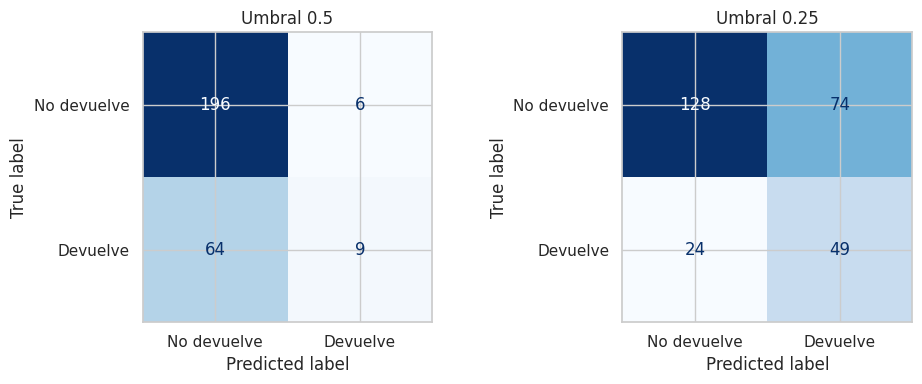

,umbral,exactitud,precision,recall,especificidad,f1,TP,FP,FN,TN
0,0.50,0.7455,0.6000,0.1233,0.9703,0.2045,9,6,64,196
1,0.25,0.6436,0.3984,0.6712,0.6337,0.5000,49,74,24,128


Exactitud de predecir siempre 'no devuelve': 0.7345


In [26]:
# ============================================================
# 5.3 Matriz de confusión y métricas: umbral 0,5 vs. umbral elegido
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
filas = []
for axi, u in zip(ax, [0.5, UMBRAL]):
    pred = (prob_test >= u).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No devuelve', 'Devuelve']).plot(
        ax=axi, cmap='Blues', values_format='d', colorbar=False)
    axi.set_title(f'Umbral {u}')
    tn, fp, fn, tp = cm.ravel()
    filas.append({'umbral': u, 'exactitud': accuracy_score(y_test, pred),
                  'precision': precision_score(y_test, pred, zero_division=0),
                  'recall': recall_score(y_test, pred), 'especificidad': tn / (tn + fp),
                  'f1': f1_score(y_test, pred), 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})
plt.tight_layout(); plt.show()

metricas_test = pd.DataFrame(filas).round(4)
display(metricas_test)
print(f"Exactitud de predecir siempre 'no devuelve': {1 - y_test.mean():.4f}")

| Métrica (prueba) | Umbral 0,5 | Umbral 0,25 |
|---|---|---|
| Devoluciones detectadas (TP) | 9 de 73 | 49 de 73 |
| Recall | 0,123 | 0,671 |
| Precisión | 0,600 | 0,398 |
| F1 | 0,205 | 0,500 |
| Especificidad | 0,970 | 0,634 |
| Exactitud | 0,746 | 0,644 |

Con umbral 0,5 la exactitud (74,6%) apenas supera a la del modelo trivial (73,5%), y el modelo deja pasar 64 de 73 devoluciones. Con 0,25 detecta 49 de 73, a cambio de 74 falsas alarmas. Como una falsa alarma cuesta un contacto y una devolución no anticipada cuesta mucho más, este intercambio es conveniente. La caída de la exactitud es esperable y no indica un peor modelo para este objetivo.

Los resultados en prueba (recall 0,671, precisión 0,398) son muy parecidos a los de validación (0,668 y 0,370), lo que respalda el umbral elegido.

In [27]:
# ============================================================
# 5.4 Análisis de errores con el umbral elegido
# ============================================================
errores = X_test.copy()
errores['real'] = y_test.values
errores['prob'] = prob_test
errores['pred'] = (prob_test >= UMBRAL).astype(int)
errores['grupo'] = np.select(
    [(errores.real == 1) & (errores.pred == 1), (errores.real == 1) & (errores.pred == 0),
     (errores.real == 0) & (errores.pred == 1), (errores.real == 0) & (errores.pred == 0)],
    ['TP', 'FN', 'FP', 'TN'], default='')

print(errores['grupo'].value_counts().to_string(), '\n')
VARS = ['compatibilidad_expectativa_1_10', 'calificacion_producto', 'dias_entrega',
        'devoluciones_previas_12m', 'descripcion_completa', 'envio_express', 'prob']
display(errores.groupby('grupo')[VARS].mean().round(3))

print("Categoría de producto dentro de cada grupo (%):")
display((pd.crosstab(errores['grupo'], errores['categoria_producto'], normalize='index') * 100).round(1))

grupo
TN    128
FP     74
TP     49
FN     24 



,compatibilidad_expectativa_1_10,calificacion_producto,dias_entrega,devoluciones_previas_12m,descripcion_completa,envio_express,prob
grupo,,,,,,,
FN,8.525,4.444,3.887,0.833,0.875,0.417,0.177
FP,7.408,4.160,4.233,1.392,0.851,0.230,0.349
TN,8.606,4.509,3.736,0.891,0.891,0.391,0.164
TP,7.279,4.026,5.337,1.551,0.776,0.184,0.424


Categoría de producto dentro de cada grupo (%):


categoria_producto,belleza,deporte,hogar,moda,tecnologia
grupo,,,,,
FN,8.3,45.8,12.5,20.8,12.5
FP,17.6,12.2,16.2,40.5,13.5
TN,17.2,18.8,25.0,13.3,25.8
TP,28.6,16.3,12.2,28.6,14.3


**Análisis de errores:**
- **Falsos negativos (24):** son muy parecidos a los verdaderos negativos en todas las variables. Por ejemplo, compatibilidad 8,53 vs 8,61, calificación 4,44 vs 4,51, días de entrega 3,89 vs 3,74, y probabilidad media 0,18 vs 0,16. Son devoluciones en pedidos que se ven normales, cuya causa no está en los datos (defectos, daños en transporte, arrepentimiento). Ningún ajuste del modelo puede separarlos con estas variables.
- **Deporte** representa el 45,8% de los falsos negativos, muy por encima de su peso en la muestra (~18%): el modelo subestima el riesgo en esa categoría.
- **Falsos positivos (74):** tienen baja compatibilidad, más devoluciones previas y el 40,5% son de moda. Son pedidos con perfil de riesgo que finalmente no se devolvieron.

## Fase 6 — Interpretación, respuesta a la pregunta guía y propuesta de despliegue

### 6.1 Interpretación del modelo
Para interpretar los efectos se ajusta un `Logit` de statsmodels sobre el mismo conjunto de entrenamiento, en unidades originales y sin regularización. Esto permite obtener p-valores, intervalos de confianza y el pseudo R² de McFadden. El modelo de scikit-learn se usa para predecir; el de statsmodels, para explicar.

In [28]:
# ============================================================
# 6.1 Interpretación con statsmodels (Logit): coeficientes, p-valores,
#     odds ratios y pseudo R² de McFadden
# Se ajusta sobre X_train en unidades originales para leer los efectos
# directamente. Precio en cientos de miles de pesos.
# ============================================================
medianas_train = X_train[NUMERICAS].median()   # imputación con train

def preparar_sm(Xd):
    Z = Xd.copy()
    Z[NUMERICAS] = Z[NUMERICAS].fillna(medianas_train)
    Z['precio_100k_cop'] = Z.pop('precio_producto_cop') / 100_000
    Z = pd.get_dummies(Z, columns=CATEGORICAS_X, drop_first=True, dtype=float)
    return sm.add_constant(Z)

X_sm = preparar_sm(X_train)
logit = sm.Logit(y_train, X_sm).fit(disp=0)
print(logit.summary())

ic = np.exp(logit.conf_int())
tabla_or = pd.DataFrame({'coef': logit.params, 'odds_ratio': np.exp(logit.params),
                         'OR_IC95_inf': ic[0], 'OR_IC95_sup': ic[1],
                         'p_valor': logit.pvalues}).drop('const').round(4)
display(tabla_or.sort_values('p_valor'))

print(f"\nPseudo R² de McFadden (statsmodels): {logit.prsquared:.4f}")
print(f"Verificación manual 1 - llf/llnull : {1 - logit.llf / logit.llnull:.4f}")

                           Logit Regression Results                           
Dep. Variable:      devuelve_producto   No. Observations:                  825
Model:                          Logit   Df Residuals:                      806
Method:                           MLE   Df Model:                           18
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.09499
Time:                        20:59:59   Log-Likelihood:                -432.98
converged:                       True   LL-Null:                       -478.43
Covariance Type:            nonrobust   LLR p-value:                 9.985e-12
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               4.6606      1.123      4.151      0.000       2.460       6.861
descuento_pct                       0.0047      0.009      0.497    

,coef,odds_ratio,OR_IC95_inf,OR_IC95_sup,p_valor
devoluciones_previas_12m,0.3483,1.4166,1.2028,1.6684,0.0000
compatibilidad_expectativa_1_10,-0.3332,0.7166,0.6370,0.8062,0.0000
calificacion_producto,-0.6873,0.5030,0.3392,0.7457,0.0006
dias_entrega,0.1122,1.1187,1.0488,1.1933,0.0007
envio_express,-0.4616,0.6303,0.4307,0.9222,0.0175
compras_12m,-0.0706,0.9318,0.8756,0.9917,0.0263
descripcion_completa,-0.4062,0.6661,0.4329,1.0250,0.0647
categoria_producto_tecnologia,-0.5159,0.5969,0.3326,1.0713,0.0838
categoria_producto_moda,0.3783,1.4598,0.8583,2.4829,0.1627
categoria_producto_hogar,-0.3324,0.7172,0.4093,1.2567,0.2454



Pseudo R² de McFadden (statsmodels): 0.0950
Verificación manual 1 - llf/llnull : 0.0950


**Pseudo R² de McFadden = 0,095** (verificado a mano con 1 − ℓ<sub>modelo</sub>/ℓ<sub>nulo</sub>). Indica que el modelo mejora la log-verosimilitud un 9,5% respecto a un modelo solo con intercepto. **No es un porcentaje de varianza explicada.** Es un valor modesto, coherente con el AUC de 0,67.

**Factores con asociación significativa (p < 0,05):**

| Variable | Odds ratio | Lectura |
|---|---|---|
| `devoluciones_previas_12m` | 1,42 | Cada devolución previa aumenta los odds 42% |
| `compatibilidad_expectativa_1_10` | 0,72 | Cada punto de compatibilidad reduce los odds 28% |
| `calificacion_producto` | 0,50 | Cada estrella más reduce los odds a la mitad |
| `dias_entrega` | 1,12 | Cada día adicional aumenta los odds 12% |
| `envio_express` | 0,63 | El envío express se asocia con 37% menos odds |
| `compras_12m` | 0,93 | Cada compra adicional reduce los odds 7% |

**Casos límite (0,05 < p < 0,10):** ficha completa (OR = 0,67; p = 0,065) y categoría tecnología (OR = 0,60; p = 0,084). Moda tiene OR = 1,46, pero con p = 0,163.

**Sin evidencia de asociación (p > 0,5):** descuento, precio, número de reseñas, antigüedad del cliente y método de pago. Este resultado coincide con los coeficientes que L1 anuló o dejó cerca de cero.

In [29]:
# ============================================================
# 6.2 Efectos en unidades de negocio (a partir del Logit de 6.1)
# Solo se incluyen los factores con p < 0,05 y dos casos límite (p < 0,10).
# ============================================================
def cambio_odds(variable, unidades=1):
    """Cambio porcentual de los odds de devolución al aumentar la variable."""
    return (np.exp(logit.params[variable] * unidades) - 1) * 100

efectos = pd.DataFrame([
    ('compatibilidad_expectativa_1_10', '+1 punto de compatibilidad', cambio_odds('compatibilidad_expectativa_1_10')),
    ('calificacion_producto',           '+0,5 estrellas de calificación', cambio_odds('calificacion_producto', 0.5)),
    ('devoluciones_previas_12m',        '+1 devolución previa del cliente', cambio_odds('devoluciones_previas_12m')),
    ('dias_entrega',                    '+1 día de entrega', cambio_odds('dias_entrega')),
    ('dias_entrega',                    '+3 días de entrega', cambio_odds('dias_entrega', 3)),
    ('envio_express',                   'Envío express (0 -> 1)', cambio_odds('envio_express')),
    ('compras_12m',                     '+1 compra en 12 meses', cambio_odds('compras_12m')),
    ('descripcion_completa',            'Ficha completa (0 -> 1)', cambio_odds('descripcion_completa')),
    ('categoria_producto_tecnologia',   'Tecnología frente a belleza', cambio_odds('categoria_producto_tecnologia')),
], columns=['variable', 'cambio', 'cambio_odds_pct'])
efectos['p_valor'] = efectos['variable'].map(logit.pvalues).round(4)
efectos['cambio_odds_pct'] = efectos['cambio_odds_pct'].round(1)
display(efectos)

,variable,cambio,cambio_odds_pct,p_valor
0,compatibilidad_expectativa_1_10,+1 punto de compatibilidad,-28.3,0.0000
1,calificacion_producto,"+0,5 estrellas de calificación",-29.1,0.0006
2,devoluciones_previas_12m,+1 devolución previa del cliente,41.7,0.0000
3,dias_entrega,+1 día de entrega,11.9,0.0007
4,dias_entrega,+3 días de entrega,40.0,0.0007
5,envio_express,Envío express (0 -> 1),-37.0,0.0175
6,compras_12m,+1 compra en 12 meses,-6.8,0.0263
7,descripcion_completa,Ficha completa (0 -> 1),-33.4,0.0647
8,categoria_producto_tecnologia,Tecnología frente a belleza,-40.3,0.0838


### 6.3 Respuesta a la pregunta guía
**¿Qué factores anticipan una devolución?** Se agrupan en tres tipos:
1. **Brecha entre lo esperado y lo recibido:** es el factor más fuerte. La compatibilidad con la expectativa y la calificación del producto son los predictores más claros. La ficha completa y la categoría apuntan en la misma dirección, aunque con evidencia más débil.
2. **Experiencia logística:** cada día de entrega aumenta el riesgo, con un salto marcado después de 8 días. El envío express se asocia con menos devoluciones.
3. **Historial del cliente:** quienes ya han devuelto tienden a volver a hacerlo; quienes compran con más frecuencia devuelven un poco menos.

**Lo que no pesa:** ni el descuento ni el método de pago se asocian con la devolución, así que no son palancas útiles para reducirla.

**¿Se puede anticipar?** Parcialmente. Con AUC de 0,67 en validación, el modelo no clasifica con precisión cada pedido, pero sí **ordena por riesgo**: con umbral 0,25 detecta dos de cada tres devoluciones en prueba.

**¿Qué explica la satisfacción?** Sobre todo el tiempo de entrega (r = −0,52), y en menor medida la calificación y la compatibilidad (sección 2.8). Satisfacción y devolución están poco relacionadas (r = −0,17), así que mejorar una no garantiza reducir la otra.

In [30]:
# ============================================================
# 6.4 Recomendaciones accionables (cifras tomadas de los resultados)
# ============================================================
tasa = lambda col, val: eda.loc[eda[col] == val, TARGET].mean() * 100
tasa_tramo = lambda col, lo, hi: eda.loc[(eda[col] > lo) & (eda[col] <= hi), TARGET].mean() * 100
fila_u = metricas_test.loc[metricas_test['umbral'] == UMBRAL].iloc[0]

recomendaciones = pd.DataFrame([
    ('Contacto postentrega a pedidos de alto riesgo', 'Servicio al cliente',
     f"Con umbral {UMBRAL} el modelo detecta {fila_u['recall']*100:.0f}% de las devoluciones en prueba "
     f"(precisión {fila_u['precision']*100:.0f}%). Ofrecer soporte, cambio de talla o guía de uso antes de que el cliente devuelva."),
    ('Reducir la brecha entre expectativa y producto', 'Catálogo',
     f"Es el factor más fuerte: +1 punto de compatibilidad reduce los odds {abs(cambio_odds('compatibilidad_expectativa_1_10')):.0f}%. "
     f"Tasa de devolución {tasa_tramo('compatibilidad_expectativa_1_10', 0, 6):.1f}% con compatibilidad <= 6 vs "
     f"{tasa_tramo('compatibilidad_expectativa_1_10', 9, 10):.1f}% con > 9. Mejorar fotos, medidas y guías de talla."),
    ('Completar las fichas de producto', 'Catálogo',
     f"Fichas incompletas: {tasa('descripcion_completa', 0):.1f}% de devolución vs {tasa('descripcion_completa', 1):.1f}%. "
     f"En el modelo ajustado el efecto es limítrofe (p = {logit.pvalues['descripcion_completa']:.3f}); es una acción de bajo costo "
     "que conviene validar con una prueba controlada."),
    ('Controlar entregas largas', 'Logística',
     f"Cada día adicional aumenta los odds {cambio_odds('dias_entrega'):.0f}%. Con más de 8 días la tasa llega a "
     f"{tasa_tramo('dias_entrega', 8, 20):.1f}%, frente a {tasa_tramo('dias_entrega', 0, 5):.1f}% hasta 5 días."),
    ('Revisar productos con baja calificación', 'Curaduría',
     f"Calificación <= 4,0: {tasa_tramo('calificacion_producto', 0, 4.0):.1f}% de devolución vs "
     f"{tasa_tramo('calificacion_producto', 4.6, 5.1):.1f}% con > 4,6."),
    ('Seguimiento a clientes con historial de devoluciones', 'Servicio al cliente',
     f"Cada devolución previa aumenta los odds {cambio_odds('devoluciones_previas_12m'):.0f}%. "
     "Orientado a acompañamiento, no a restricciones al cliente."),
    ('No usar el descuento ni el método de pago como palanca antidevolución', 'Comercial',
     f"Descuento: p = {logit.pvalues['descuento_pct']:.2f}; método de pago: todos los p > 0,5. "
     "No hay evidencia de que se asocien con la devolución."),
    ('Registrar el motivo de devolución', 'Datos',
     "Los falsos negativos se parecen a los pedidos sin devolución (sección 5.4); "
     "sin el motivo, el modelo no puede distinguirlos."),
], columns=['recomendación', 'área', 'evidencia'])
display(recomendaciones)

,recomendación,área,evidencia
0,Contacto postentrega a pedidos de alto riesgo,Servicio al cliente,"Con umbral 0.25 el modelo detecta 67% de las devoluciones en prueba (precisión 40%). Ofrecer soporte, cambio de talla o guía de uso antes de que el cliente devuelva."
1,Reducir la brecha entre expectativa y producto,Catálogo,"Es el factor más fuerte: +1 punto de compatibilidad reduce los odds 28%. Tasa de devolución 49.5% con compatibilidad <= 6 vs 17.3% con > 9. Mejorar fotos, medidas y guías de talla."
2,Completar las fichas de producto,Catálogo,Fichas incompletas: 35.5% de devolución vs 25.0%. En el modelo ajustado el efecto es limítrofe (p = 0.065); es una acción de bajo costo que conviene validar con una prueba controlada.
3,Controlar entregas largas,Logística,"Cada día adicional aumenta los odds 12%. Con más de 8 días la tasa llega a 41.9%, frente a 23.9% hasta 5 días."
4,Revisar productos con baja calificación,Curaduría,"Calificación <= 4,0: 33.5% de devolución vs 18.0% con > 4,6."
5,Seguimiento a clientes con historial de devoluciones,Servicio al cliente,"Cada devolución previa aumenta los odds 42%. Orientado a acompañamiento, no a restricciones al cliente."
6,No usar el descuento ni el método de pago como palanca antidevolución,Comercial,"Descuento: p = 0.62; método de pago: todos los p > 0,5. No hay evidencia de que se asocien con la devolución."
7,Registrar el motivo de devolución,Datos,"Los falsos negativos se parecen a los pedidos sin devolución (sección 5.4); sin el motivo, el modelo no puede distinguirlos."


Las recomendaciones de catálogo y logística se basan en asociaciones observadas. Antes de aplicarlas a gran escala conviene probarlas en un grupo controlado, porque los datos no permiten afirmar que sean causales.

In [31]:
# ============================================================
# 6.5 Propuesta de despliegue
# ============================================================
despliegue = pd.DataFrame([
    ('Momento de uso', 'Al confirmarse la entrega, dentro de la ventana de devolución'),
    ('Entrada', 'Las 13 variables de X, disponibles en ese momento'),
    ('Salida', 'Probabilidad de devolución entre 0 y 1'),
    ('Regla de decisión', f"Si la probabilidad >= {UMBRAL}, el pedido entra a la lista de contacto postentrega"),
    ('Volumen esperado', f"{fila_u['TP'] + fila_u['FP']:.0f} de {len(y_test)} pedidos de prueba "
                         f"({(fila_u['TP'] + fila_u['FP']) / len(y_test) * 100:.0f}%) serían marcados"),
    ('Usuarios', 'Servicio al cliente (contacto), Catálogo (fichas y fotos), Logística (tiempos de entrega)'),
    ('Seguimiento', 'Recalcular periódicamente el AUC y la tasa de devolución con pedidos nuevos; reentrenar si cambian'),
    ('Salvaguarda', 'El modelo no bloquea pedidos ni penaliza clientes: solo prioriza atención humana'),
], columns=['aspecto', 'definición'])
display(despliegue)

,aspecto,definición
0,Momento de uso,"Al confirmarse la entrega, dentro de la ventana de devolución"
1,Entrada,"Las 13 variables de X, disponibles en ese momento"
2,Salida,Probabilidad de devolución entre 0 y 1
3,Regla de decisión,"Si la probabilidad >= 0.25, el pedido entra a la lista de contacto postentrega"
4,Volumen esperado,123 de 275 pedidos de prueba (45%) serían marcados
5,Usuarios,"Servicio al cliente (contacto), Catálogo (fichas y fotos), Logística (tiempos de entrega)"
6,Seguimiento,Recalcular periódicamente el AUC y la tasa de devolución con pedidos nuevos; reentrenar si cambian
7,Salvaguarda,El modelo no bloquea pedidos ni penaliza clientes: solo prioriza atención humana


In [32]:
# ============================================================
# 6.6 Limitaciones del análisis
# ============================================================
sd_cv = grid_log.cv_results_['std_test_score'][grid_log.best_index_]
limitaciones = pd.DataFrame([
    ('Capacidad predictiva moderada',
     f"AUC de validación {auc_cv:.3f} (sd {sd_cv:.3f} entre pliegues) y pseudo R² de {logit.prsquared:.3f}. "
     "El modelo sirve para priorizar, no para decidir automáticamente."),
    ('Diferencia entre prueba y validación',
     f"El AUC de prueba ({auc_test:.3f}) supera al de validación ({auc_cv:.3f}); esa partición resultó favorable. "
     "La validación cruzada es la estimación más conservadora."),
    ('Momento de la predicción',
     "dias_entrega y compatibilidad_expectativa solo se conocen tras la entrega; por eso el modelo no sirve antes del despacho."),
    ('Asociación, no causalidad',
     "Los datos son observacionales: los odds ratios describen asociaciones y las intervenciones deben validarse con pruebas controladas."),
    ('Motivo de devolución no registrado',
     "No se distingue entre defecto, talla, arrepentimiento o daño en transporte."),
    ('Metadatos ausentes',
     "Se desconoce el periodo, el mercado y la política de devoluciones; no se puede evaluar estacionalidad."),
    ('Tamaño de muestra',
     f"{len(datos)} pedidos y {int(y.sum())} devoluciones; efectos por categoría con intervalos amplios."),
], columns=['limitación', 'descripción'])
display(limitaciones)

,limitación,descripción
0,Capacidad predictiva moderada,"AUC de validación 0.667 (sd 0.041 entre pliegues) y pseudo R² de 0.095. El modelo sirve para priorizar, no para decidir automáticamente."
1,Diferencia entre prueba y validación,El AUC de prueba (0.715) supera al de validación (0.667); esa partición resultó favorable. La validación cruzada es la estimación más conservadora.
2,Momento de la predicción,dias_entrega y compatibilidad_expectativa solo se conocen tras la entrega; por eso el modelo no sirve antes del despacho.
3,"Asociación, no causalidad",Los datos son observacionales: los odds ratios describen asociaciones y las intervenciones deben validarse con pruebas controladas.
4,Motivo de devolución no registrado,"No se distingue entre defecto, talla, arrepentimiento o daño en transporte."
5,Metadatos ausentes,"Se desconoce el periodo, el mercado y la política de devoluciones; no se puede evaluar estacionalidad."
6,Tamaño de muestra,1100 pedidos y 293 devoluciones; efectos por categoría con intervalos amplios.


## Fuentes y uso de IA
- Material del curso Analítica de Datos 2026-2 (sesiones 5 a 20).
- Documentación de scikit-learn, pandas y statsmodels.
- Se utilizó IA como apoyo para generar y revisar parte del código y del texto. El equipo revisó cada celda, verificó que los valores del texto coincidieran con las salidas y es responsable de las decisiones y conclusiones.